# Module `visualization.py`

Ce notebook montre comment visualiser le graphe CESIPATH avec `matplotlib`, afficher les couts sur les aretes et avancer d'un tour dynamique avec un bouton en forme de fleche.

In [1]:
%matplotlib notebook

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from cesipath.graph_generator import GraphGenerator
from cesipath.models import GraphGenerationConfig
from cesipath.visualization import GraphVisualizer

In [3]:
config = GraphGenerationConfig(
    node_count=8,
    seed=42,
    auto_density_profile=True,
    forbidden_rate=0.1,
    surcharge_rate=0.25,
    dynamic_sigma=0.18,
    dynamic_mean_reversion_strength=0.35,
    dynamic_max_multiplier=1.8,
    dynamic_forbid_probability=0.03,
    dynamic_restore_probability=0.2,
    dynamic_max_disabled_ratio=0.2,
)
generator = GraphGenerator(config)
instance = generator.generate()
instance.summary()

{'node_count': 8,
 'base_edge_count': 16,
 'residual_edge_count': 14,
 'base_density': 0.5714,
 'residual_density': 0.5,
 'residual_average_degree': 3.5,
 'forbidden_edge_count': 2,
 'surcharged_edge_count': 1,
 'uniform_demand': 8,
 'vehicle_capacity': 40,
 'edge_density_target': 0.6,
 'min_base_density': 0.45,
 'max_base_density': 0.75,
 'min_residual_density': 0.35,
 'max_residual_density': 0.65,
 'min_average_residual_degree': 2.08,
 'dynamic_sigma': 0.18,
 'dynamic_forbid_probability': 0.1,
 'dynamic_restore_probability': 0.2,
 'minimum_route_count': 2}

<IPython.core.display.Javascript object>

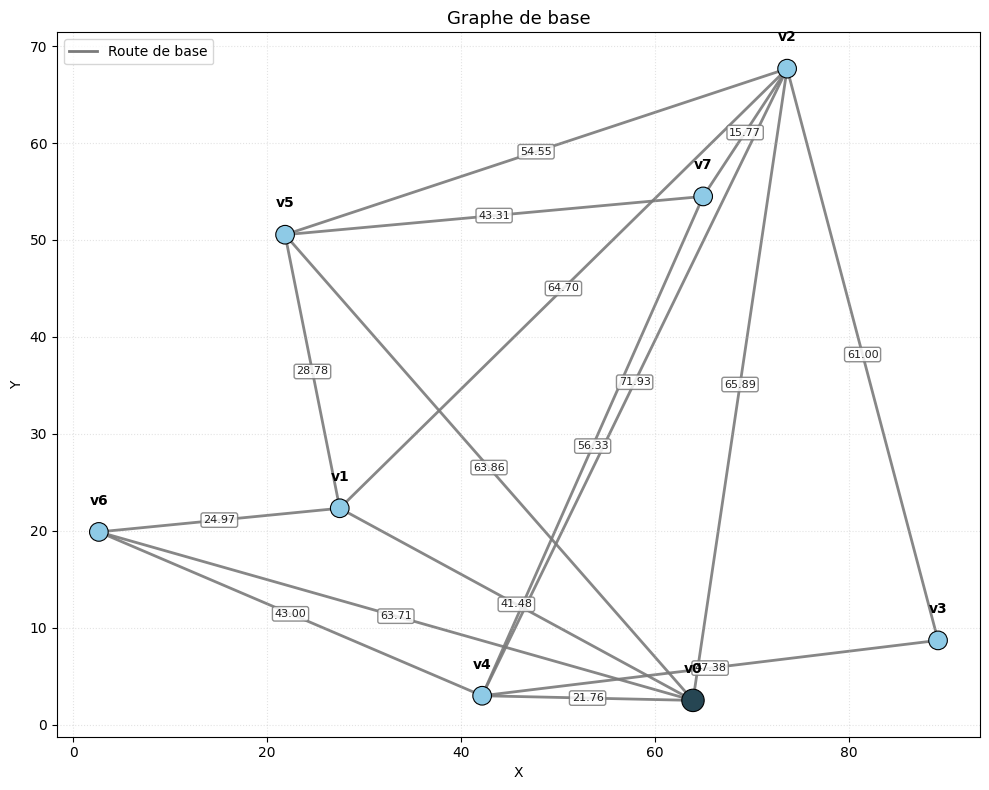

In [4]:
visualizer = GraphVisualizer(instance, generator)
visualizer.show_base_graph()

<IPython.core.display.Javascript object>

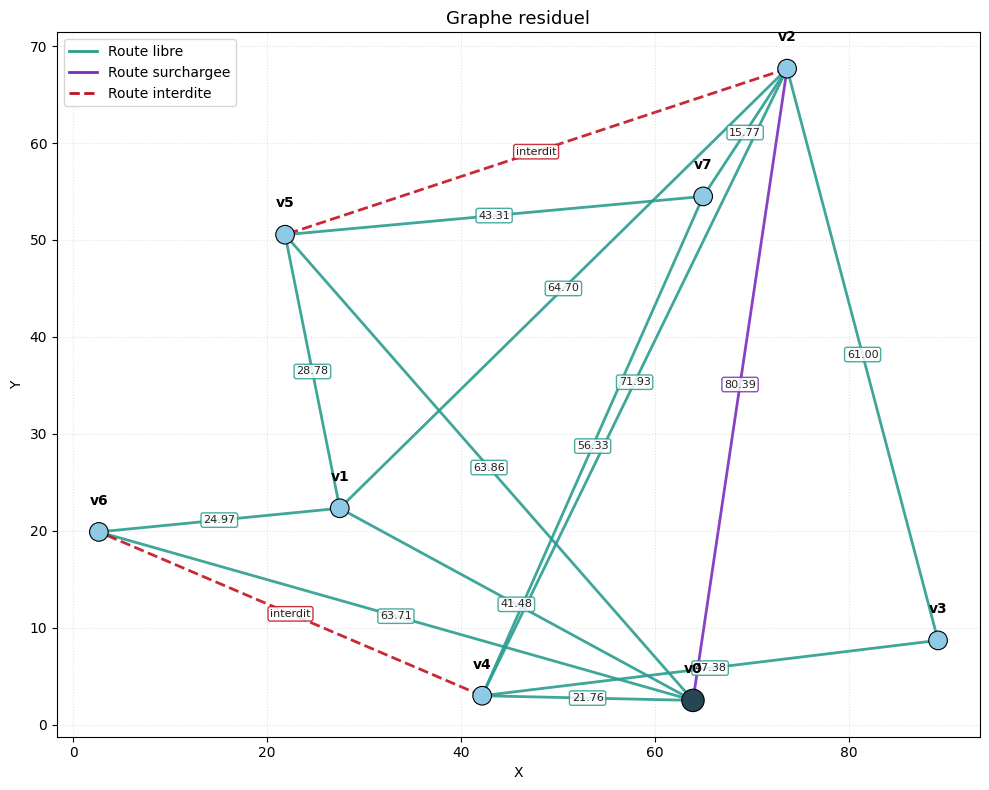

In [5]:
visualizer.show_residual_graph()

<IPython.core.display.Javascript object>

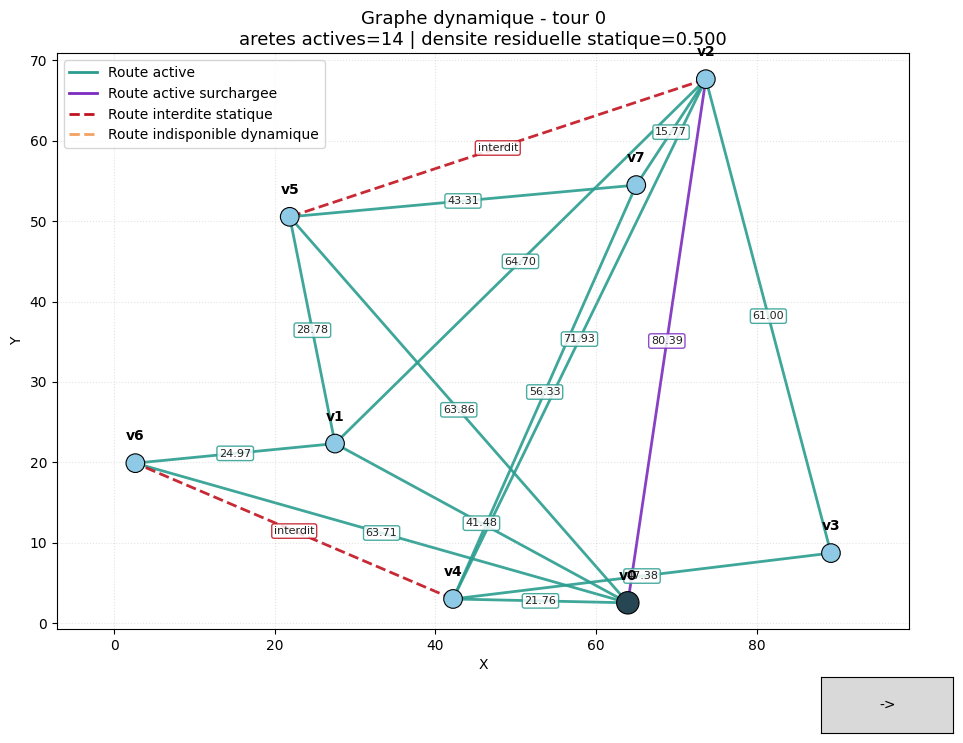

In [6]:
session = visualizer.show_dynamic_graph()
session.fig

In [ ]:
# Fallback si le bouton matplotlib ne reagit pas dans ton notebook :
# execute cette cellule pour avancer d'un tour.
visualizer.advance_session(session)
session.fig

Lecture de la visualisation :

- les aretes grises representent le graphe de base ;
- les aretes violettes sont surchargees ;
- les aretes rouges en pointilles sont interdites statiquement ;
- les aretes orange en pointilles sont temporairement indisponibles a cause de la dynamique ;
- le bouton `->` fait avancer le reseau d'un tour, recalcule les couts locaux puis la completion metrique avec Dijkstra ;
- si ton frontend Jupyter ne gere pas bien les widgets `matplotlib`, la cellule de fallback permet d'avancer manuellement.